# Notebook 1 — Analyse Exploratoire du Dataset Cardio

Dans ce notebook, nous explorons le dataset **cardio** qui contient des informations
sur des patients (âge, sexe, taille, poids, tension, cholestérol, mode de vie, etc.)
et une variable cible `cardio` (0 = pas de maladie, 1 = maladie cardiovasculaire).

L'objectif est notamment de répondre à la question :
**« Peut-on prédire le risque cardiovasculaire d’une personne à partir de données cliniques  et    comportementales simples, grâce à des méthodes de classification supervisée ?
 »**


## 1. Imports et chargement des données

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv('../data_clean/cardio_clean.csv')
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 2. Dimensions, types et valeurs manquantes

In [4]:

df.shape


(70000, 13)

In [5]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:

df.isna().sum()


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## 3. Création de variables dérivées : âge en années et BMI

Dans le dataset cardio, l'âge est souvent exprimé en jours. Nous le convertissons en années.
Nous créons également l'indice de masse corporelle (BMI = poids / taille²).


In [7]:

df['age_years'] = (df['age'] / 365).round(1)
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df[['age', 'age_years', 'height', 'weight', 'BMI']].head()


,age,age_years,height,weight,BMI
0,18393,50.4,168,62.0,21.967120
1,20228,55.4,156,85.0,34.927679
2,18857,51.7,165,64.0,23.507805
3,17623,48.3,169,82.0,28.710479
4,17474,47.9,156,56.0,23.011177


## 4. Distribution de la variable cible `cardio`

In [8]:

df['cardio'].value_counts(normalize=True)


cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

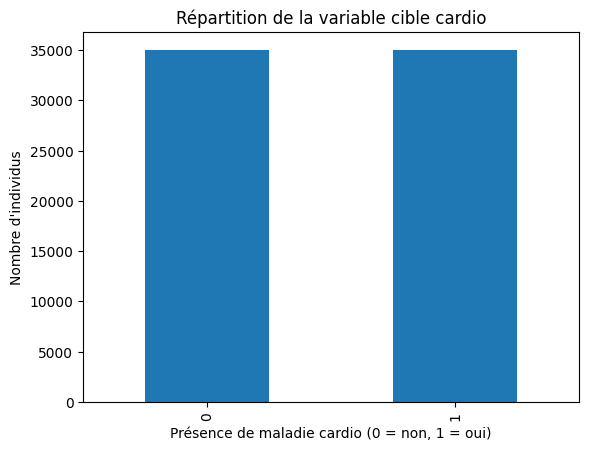

In [9]:

df['cardio'].value_counts().plot(kind='bar')
plt.title("Répartition de la variable cible cardio")
plt.xlabel("Présence de maladie cardio (0 = non, 1 = oui)")
plt.ylabel("Nombre d'individus")
plt.show()


## 5. Distribution du BMI selon le risque cardio

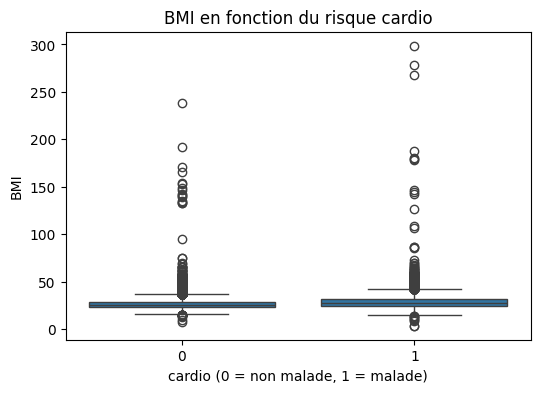

In [10]:

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='cardio', y='BMI')
plt.title("BMI en fonction du risque cardio")
plt.xlabel("cardio (0 = non malade, 1 = malade)")
plt.ylabel("BMI")
plt.show()


## 6. Activité physique et risque cardio

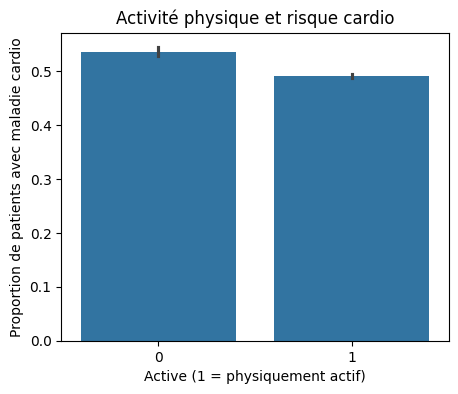

In [11]:

plt.figure(figsize=(5,4))
sns.barplot(data=df, x='active', y='cardio')
plt.title("Activité physique et risque cardio")
plt.xlabel("Active (1 = physiquement actif)")
plt.ylabel("Proportion de patients avec maladie cardio")
plt.show()


## 7. Matrice de corrélation

Nous observons les corrélations entre les principales variables de style de vie
(BMI, pression artérielle, cholestérol, glucose, activité, tabac, alcool)
et la variable cible `cardio`.


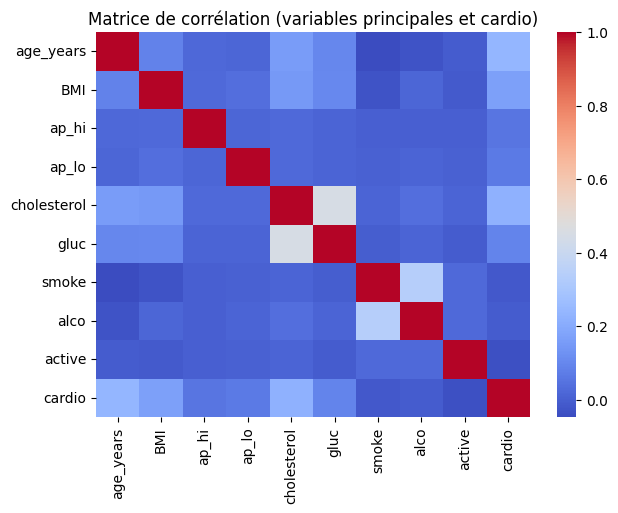

In [16]:

cols_of_interest = ['age_years', 'BMI', 'ap_hi', 'ap_lo',
                    'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

plt.figure(figsize=(7,5))
sns.heatmap(df[cols_of_interest].corr(), annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation (variables principales et cardio)")
plt.show()
